# BigCloneBench Type 2 Temporary Small Graph Inspection


In [1]:
from pathlib import Path
import html
import json
import pickle
import sys

import matplotlib.pyplot as plt
import networkx as nx
import pandas as pd
from IPython.display import HTML, display
from tqdm.auto import tqdm


def find_project_root(start: Path) -> Path:
    for candidate in [start, *start.parents]:
        if (candidate / "spectral_code").exists() and (candidate / "pipelines").exists():
            return candidate
    raise RuntimeError("Project root not found.")


PROJECT_ROOT = find_project_root(Path.cwd())
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

from spectral_code.utils.dataset_paths import bcb_type_dir, output_root_for

CLONE_TYPE = 2
DATA_DIR = bcb_type_dir(CLONE_TYPE)
OUTPUT_ROOT = output_root_for("bcb", CLONE_TYPE)
GRAPH_MANIFEST_PATH = OUTPUT_ROOT / "clean_graphs" / "graph_shards_manifest.json"
GRAPH_TYPES = ["ast", "cfg", "ddg", "pdg", "cpg"]
SMALL_NODE_LIMIT = 6
MAX_EXAMPLES = 8

if not GRAPH_MANIFEST_PATH.exists():
    raise FileNotFoundError(f"Graph manifest not found: {GRAPH_MANIFEST_PATH}. Run ../run_pipeline/02_extract_graphs.py first.")

manifest = json.loads(GRAPH_MANIFEST_PATH.read_text(encoding="utf-8"))
print("Prepared data:", DATA_DIR)
print("Output root:", OUTPUT_ROOT)
print("Graph methods:", manifest.get("total_methods"))


Prepared data: C:\Users\koush\PyProjects\spectrals\data\bcb\type2
Output root: C:\Users\koush\PyProjects\spectrals\outputs\bcb\type2
Graph methods: 953


c:\Users\koush\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
small_rows = []
method_layer_counts = {}
all_method_ids = set()

for shard_path in tqdm(manifest.get("shards", []), desc="Scanning graph shards", unit="shard"):
    with Path(shard_path).open("rb") as f:
        shard = pickle.load(f)
    for method_id, layers in shard.items():
        all_method_ids.add(str(method_id))
        for graph_type in GRAPH_TYPES:
            graph = layers.get(graph_type)
            if graph is None:
                nodes = 0
                edges = 0
            else:
                nodes = graph.number_of_nodes()
                edges = graph.number_of_edges()
            if nodes <= SMALL_NODE_LIMIT:
                small_rows.append({
                    "method_id": str(method_id),
                    "graph_type": graph_type,
                    "nodes": int(nodes),
                    "edges": int(edges),
                })
                method_layer_counts.setdefault(str(method_id), 0)
                method_layer_counts[str(method_id)] += 1

small_df = pd.DataFrame(small_rows)
summary_df = (
    small_df.groupby("graph_type")
    .agg(small_layers=("method_id", "count"), unique_methods=("method_id", "nunique"), avg_nodes=("nodes", "mean"), avg_edges=("edges", "mean"))
    .reset_index()
    if not small_df.empty else pd.DataFrame(columns=["graph_type", "small_layers", "unique_methods", "avg_nodes", "avg_edges"])
)
summary_df["total_methods"] = len(all_method_ids)
summary_df["unique_method_fraction"] = summary_df["unique_methods"] / max(1, len(all_method_ids))

display(summary_df)
display(small_df.head(30))

if small_df.empty:
    example_method_ids = []
else:
    ranked = sorted(method_layer_counts.items(), key=lambda item: item[1], reverse=True)
    example_method_ids = [method_id for method_id, _ in ranked[:MAX_EXAMPLES]]
print("Example method ids:", example_method_ids)


Scanning graph shards: 100%|██████████| 1/1 [00:01<00:00,  1.28s/shard]


,graph_type,small_layers,unique_methods,avg_nodes,avg_edges,total_methods,unique_method_fraction
0,cfg,8,8,3.25,2.25,953,0.008395
1,ddg,8,8,6.00,8.50,953,0.008395
2,pdg,8,8,6.00,8.50,953,0.008395


,method_id,graph_type,nodes,edges
0,1974719,cfg,3,2
1,1974719,ddg,6,8
2,1974719,pdg,6,8
3,1974720,cfg,3,2
4,1974720,ddg,6,8
5,1974720,pdg,6,8
6,22966750,cfg,4,3
7,22966750,ddg,6,10
8,22966750,pdg,6,10
9,22966751,cfg,4,3


Example method ids: ['1974719', '1974720', '22966750', '22966751', '23422445', '23422446', '4644121', '4644122']


In [3]:
def load_code_for_ids(path: Path, wanted_ids: set[str]) -> dict[str, str]:
    code_map = {}
    with path.open("r", encoding="utf-8") as f:
        for line in f:
            row = json.loads(line)
            method_id = str(row["idx"])
            if method_id in wanted_ids:
                code_map[method_id] = row["func"]
                if len(code_map) == len(wanted_ids):
                    break
    return code_map


def load_graphs_for_ids(manifest: dict, wanted_ids: set[str]) -> dict[str, dict]:
    graphs = {}
    for shard_path in manifest.get("shards", []):
        with Path(shard_path).open("rb") as f:
            shard = pickle.load(f)
        for method_id in list(wanted_ids - set(graphs)):
            if method_id in shard:
                graphs[method_id] = shard[method_id]
        if len(graphs) == len(wanted_ids):
            break
    return graphs


code_map = load_code_for_ids(DATA_DIR / "data.jsonl", set(example_method_ids))
graph_map = load_graphs_for_ids(manifest, set(example_method_ids))
print("Loaded examples:", len(code_map), len(graph_map))


Loaded examples: 8 8


,method_id,graph_type,nodes,edges
0,1974719,cfg,3,2
1,1974719,ddg,6,8
2,1974719,pdg,6,8


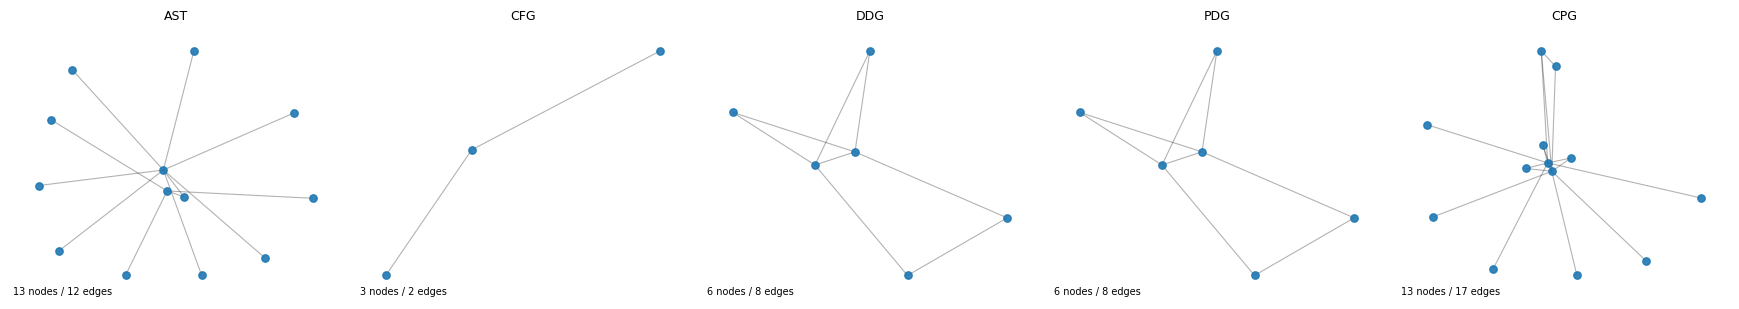

,method_id,graph_type,nodes,edges
3,1974720,cfg,3,2
4,1974720,ddg,6,8
5,1974720,pdg,6,8


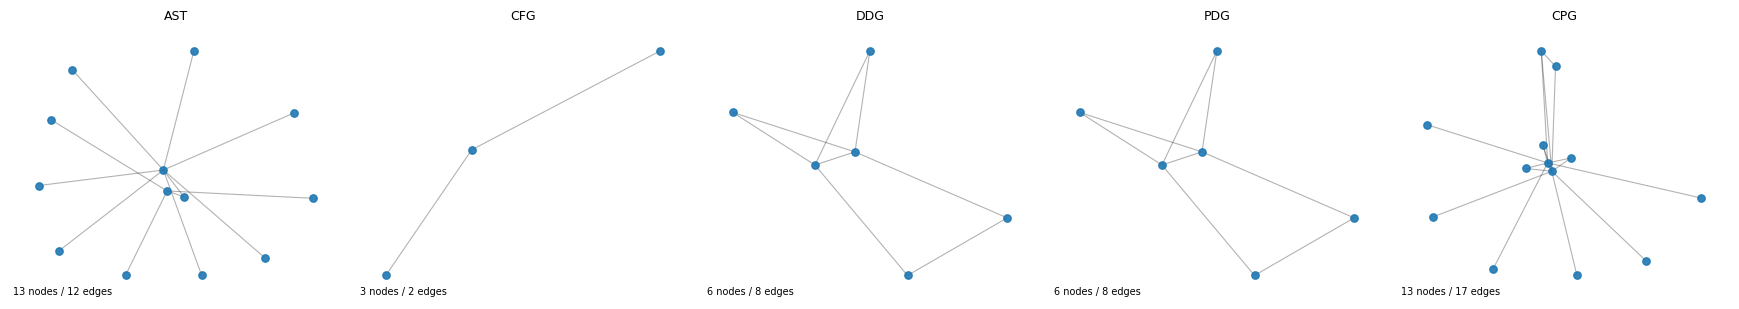

,method_id,graph_type,nodes,edges
6,22966750,cfg,4,3
7,22966750,ddg,6,10
8,22966750,pdg,6,10


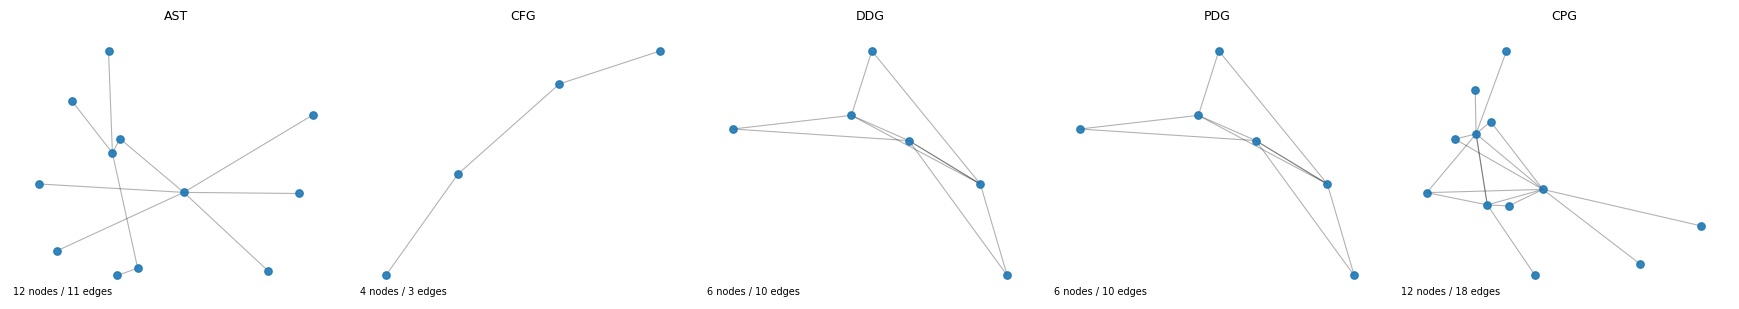

,method_id,graph_type,nodes,edges
9,22966751,cfg,4,3
10,22966751,ddg,6,10
11,22966751,pdg,6,10


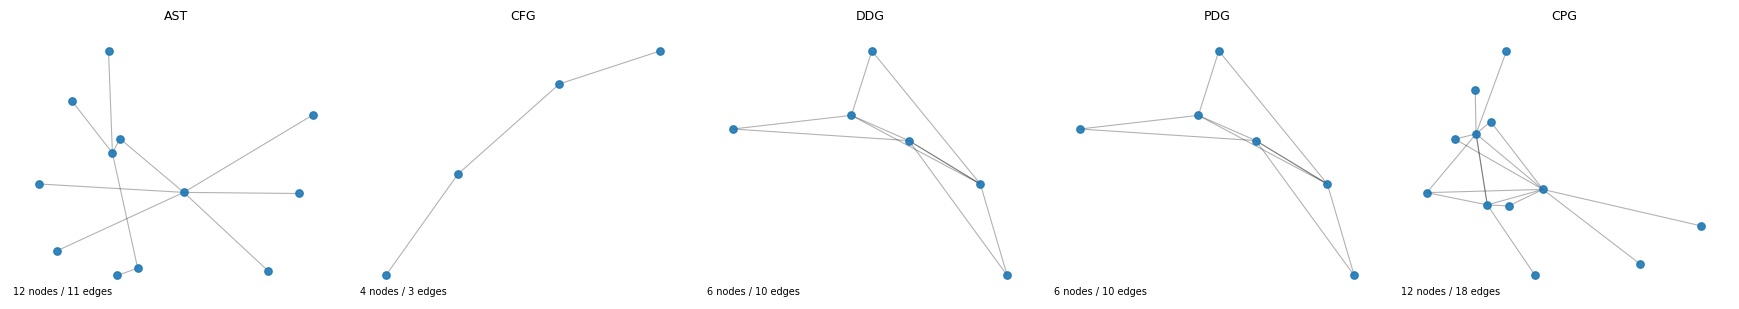

,method_id,graph_type,nodes,edges
12,23422445,cfg,3,2
13,23422445,ddg,6,8
14,23422445,pdg,6,8


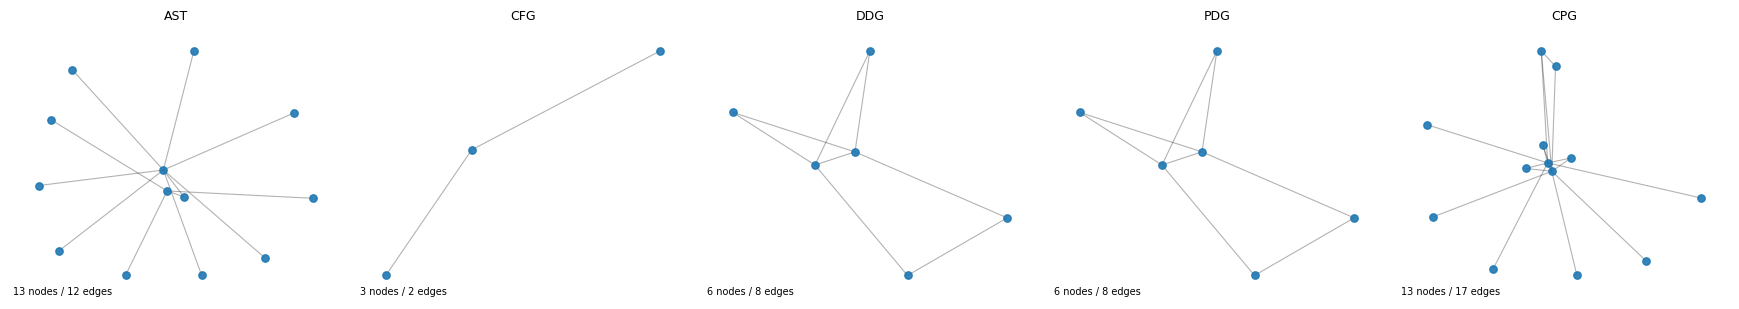

,method_id,graph_type,nodes,edges
15,23422446,cfg,3,2
16,23422446,ddg,6,8
17,23422446,pdg,6,8


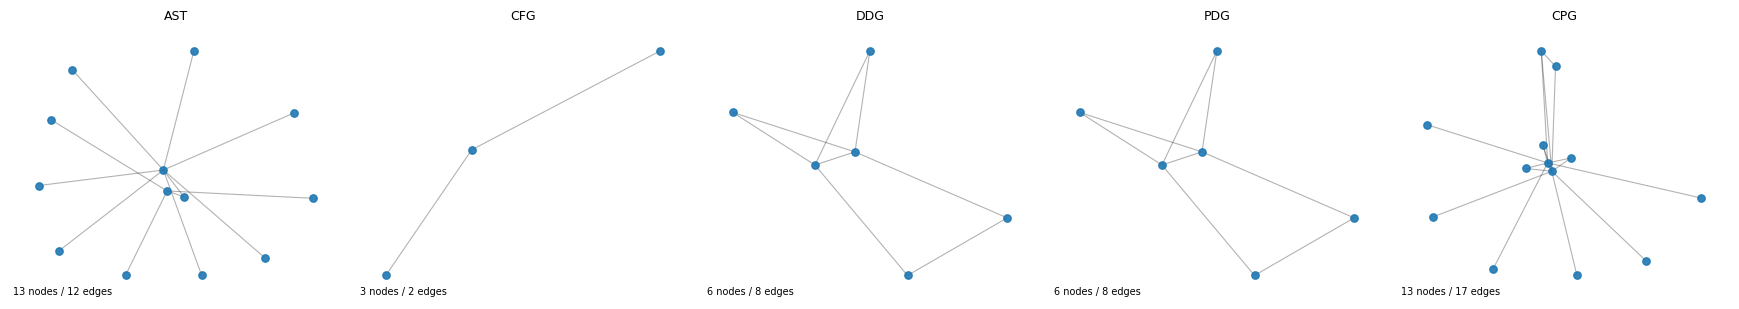

,method_id,graph_type,nodes,edges
18,4644121,cfg,3,2
19,4644121,ddg,6,8
20,4644121,pdg,6,8


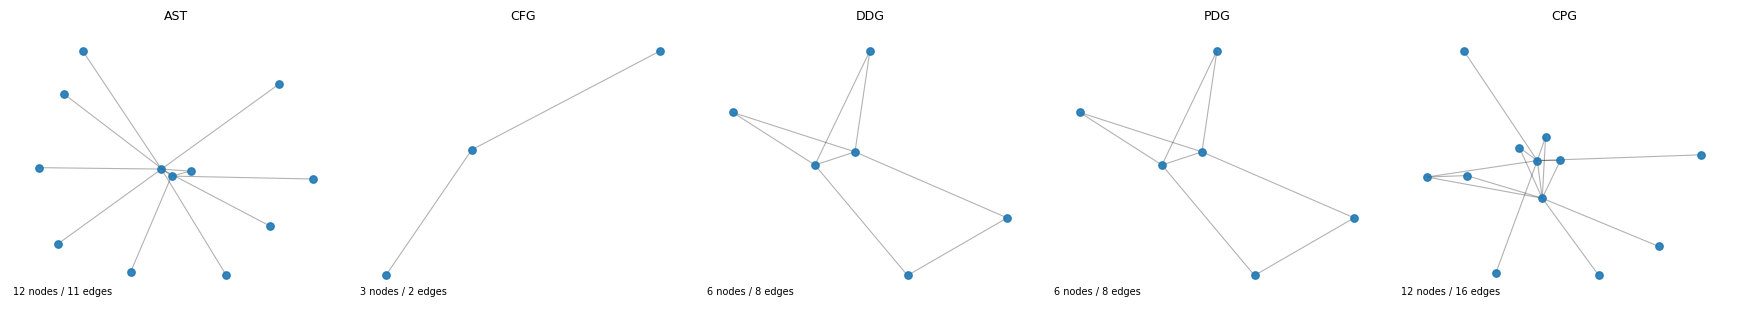

,method_id,graph_type,nodes,edges
21,4644122,cfg,3,2
22,4644122,ddg,6,8
23,4644122,pdg,6,8


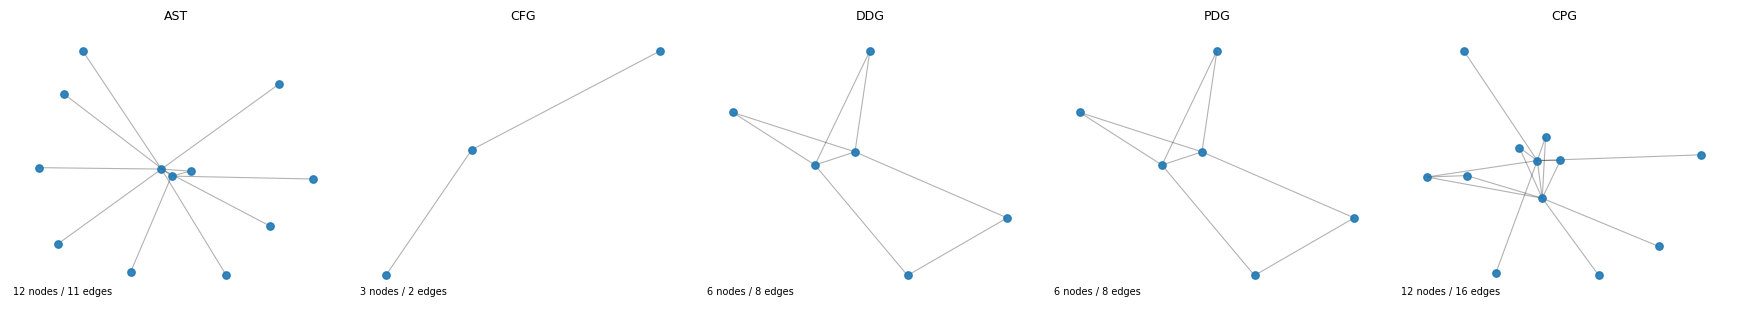

In [4]:
def draw_graph(graph: nx.DiGraph | None, title: str, ax) -> None:
    ax.set_title(title, fontsize=9)
    ax.axis("off")
    if graph is None or graph.number_of_nodes() == 0:
        ax.text(0.5, 0.5, "empty", ha="center", va="center")
        return
    graph = nx.DiGraph(graph)
    shown = graph if graph.number_of_nodes() <= 120 else graph.subgraph(list(graph.nodes())[:120]).copy()
    pos = nx.spring_layout(shown, seed=42)
    nx.draw_networkx_edges(shown, pos, ax=ax, arrows=False, alpha=0.3, width=0.8)
    nx.draw_networkx_nodes(shown, pos, ax=ax, node_size=28, alpha=0.9)
    ax.text(0.01, 0.02, f"{graph.number_of_nodes()} nodes / {graph.number_of_edges()} edges", transform=ax.transAxes, fontsize=7)


def show_method(method_id: str) -> None:
    code = html.escape(code_map.get(method_id, ""))
    small_layers = small_df[small_df["method_id"] == method_id].sort_values("graph_type")
    display(HTML(f"""
    <h3>method {html.escape(method_id)}</h3>
    <pre style="white-space:pre-wrap;font-size:12px;line-height:1.35;border:1px solid #d0d7de;padding:10px;border-radius:6px;max-height:420px;overflow:auto;">{code}</pre>
    """))
    display(small_layers)

    fig, axes = plt.subplots(1, len(GRAPH_TYPES), figsize=(3.5 * len(GRAPH_TYPES), 3.2))
    for ax, graph_type in zip(axes, GRAPH_TYPES):
        draw_graph(graph_map.get(method_id, {}).get(graph_type), graph_type.upper(), ax)
    plt.tight_layout()
    plt.show()


for method_id in example_method_ids:
    show_method(method_id)
